## Learning from images

In [1]:
# importing libs 
from torchvision import datasets 
import torch 
import torch.nn as nn 
import torch.optim as optim
from matplotlib import pyplot as plt 
from torchvision import transforms 

In [2]:
# downloading CIFAR-10 data using torchvison 
data_path = "data/"
cifar10 = datasets.CIFAR10(data_path, train=True, download=False) 
cifar10_val = datasets.CIFAR10(data_path, train=False, download=False)


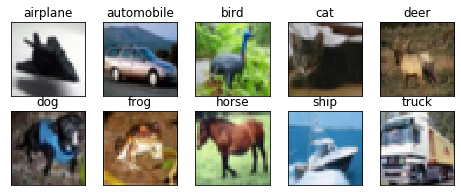

In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

fig = plt.figure(figsize=(8,3))
num_classes = len(class_names) 
for i in range(num_classes):
    ax = fig.add_subplot(2,5,1+i, xticks=[], yticks=[])
    ax.set_title(class_names[i])
    img = next(img for img, label in cifar10 if label == i) 
    plt.imshow(img)
plt.show()

(<class 'torchvision.datasets.cifar.CIFAR10'>, <class 'torchvision.datasets.vision.VisionDataset'>, <class 'torch.utils.data.dataset.Dataset'>, <class 'object'>)
50000
<PIL.Image.Image image mode=RGB size=32x32 at 0x7FA02F1C4110> 1 automobile


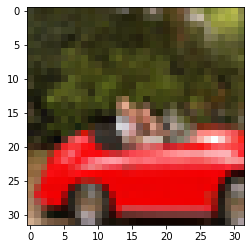

In [5]:
print(type(cifar10).__mro__)

# the dataset class
"""
torch.utils.data.Dataset is an object that is required to implement two methods: __len__ (returns the number of items in the dataset) and __getitem__ (returns the items consisting of a sample and its corresponding label (an integer index)).
NB: When python object is equipped with the __len__ method, we can pass it as an arg to the len python bult-in function. 

Concept of a Pytorch Dataset objects does not necessarily hold data, but it provides uniform access to it through __len__ and __getitem__.

eg. below 
"""
print(len(cifar10))

"""
Similarily, since the dataset is equipped with the __getitem__ method, we can use the standard subscrupt for indexing tuples and list access individual items.  
eg below using PIL 
"""
img, label = cifar10[99] 
print(img, label, class_names[label])
plt.imshow(img) 
plt.show()

In [6]:
# Dataset transforms 
"""
torchvision.transform is used to convert PIL image to pytorch tensor before anything can be done with it. 
This module defines a set of composable, function-like objects that can be
passed as an argument to a torchvision dataset such as datasets.CIFAR10(...), and
that perform transformations on the data after it is loaded but before it is returned by
__getitem__.
 """
 
dir(transforms)

"Among those transforms, we can spot ToTensor, which turns Numpy arrays and PIL images to tensor and takes care of the dimensionality of the output tensor as C x H x W."


'Among those transforms, we can spot ToTensor, which turns Numpy arrays and PIL images to tensor and takes care of the dimensionality of the output tensor as C x H x W.'

In [6]:
to_tensor = transforms.ToTensor() 
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

In [7]:
# passing the transform directyl as an args to dataset 
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform=transforms.ToTensor()) 
img_t, _ = tensor_cifar10[99]
print(type(img_t))
print(img_t.shape, img_t.dtype)

"""
Whereas the values in the original PIL image ranged from 0 to 255 (8 bits per chan-
nel), the ToTensor transform turns the data into a 32-bit floating-point per channel,
scaling the values down from 0.0 to 1.0. Let’s verify that:
"""
print("\n")
print(img_t.min(), img_t.max())

<class 'torch.Tensor'>
torch.Size([3, 32, 32]) torch.float32


tensor(0.) tensor(1.)


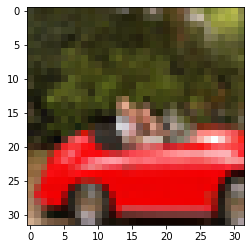

In [8]:
# verifying we getting the same image output. # we fists change the order from C x H x W to H x W x C using tensor.permute() method. permute change the order of the axes to match what matplotlib expects. 
plt.imshow(img_t.permute(1, 2 , 0))
plt.show()


In [9]:
# Normalizing Data 
"""
Transforms are really handy because we can chain them using transforms.Compose,
and they can handle normalization and data augmentation transparently, directly in
the data loader.
"""
# staking all tesnors returned by dataset along an extra dimentsion 
imgs = torch.stack([img_t for img_t,_ in tensor_cifar10], dim=3)
print(imgs.shape)
print(imgs.view(3,-1).shape) #view keeps all the three channels and merges all the remaining dimensions into one. ie. 3x32x32 to 3x1024 vectors.  

# calculating the mean and std 
print("Mean: ", imgs.view(3,-1).mean(dim=1))
print("Std: ", imgs.view(3, -1).std(dim=1))




torch.Size([3, 32, 32, 50000])
torch.Size([3, 51200000])
Mean:  tensor([0.4915, 0.4823, 0.4468])
Std:  tensor([0.2470, 0.2435, 0.2616])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


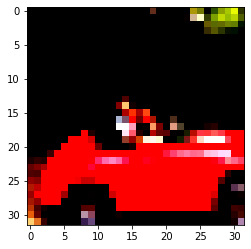

In [10]:
# initializing Normalize transform with the values above. 
transformed_cifar_10 = datasets.CIFAR10(data_path, train=True, download=False, transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))]))

img_t, _ = transformed_cifar_10[99]

plt.imshow(img_t.permute(1,2,0))
plt.show()


#### Distinguishing birds from airplanes 


In [18]:
cifar10 = datasets.CIFAR10(data_path, train=True, download=False,transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))])) 
cifar10_val = datasets.CIFAR10(data_path, train=False, download=False,transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))]))

In [19]:
# building data set 

# filtering the cifar10 data and remap the labels. 
label_map = {0: 0, 2: 1}
class_names = ['airplane','bird']

cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0,2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0,2]]

n_out = 2 # number of outputs 
model = nn.Sequential(nn.Linear(32*32*3, 512,),
                        nn.Tanh(),
                        nn.Linear(512, 128,),
                        nn.Tanh(),
                        nn.Linear(128, 64,),
                        nn.Tanh(),
                        nn.Linear(64, n_out,),
                        nn.Softmax(dim=1)
                        )


In [20]:
# representing the output as probabilities 
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum()

x = torch.tensor([1.0, 2.0, 3.0])
print(softmax(x)) # using the softmax function defined above 

print("\n")
x = torch.tensor([[1.0, 2.0, 3.0],[1.0, 2.0, 3.0]]) 
softmax = nn.Softmax(dim=1) # using softmax function from nn module and applying on a tensor. 
print(softmax(x))

tensor([0.0900, 0.2447, 0.6652])


tensor([[0.0900, 0.2447, 0.6652],
        [0.0900, 0.2447, 0.6652]])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


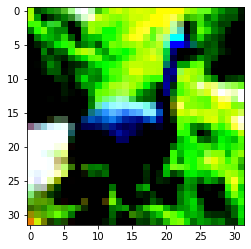

In [21]:
img, _ = cifar2[0]
plt.imshow(img.permute(1, 2, 0))
plt.show()

In [22]:
# To call the model we need to reshape our data from 3x32x32 image to a 1D tensor and add an extra dimension in the zeroth position. 
img_batch = img.view(-1).unsqueeze(0)

# invoking our model
out = model(img_batch)
_, index = torch.max(out, dim=1) 
index

tensor([0])

In [23]:
# changing from softmax to LogSoftmax and in instantiating the NLL loss 
model = nn.Sequential(nn.Linear(32*32*3, 512,),
                        nn.Tanh(),
                        nn.Linear(512, 128,),
                        nn.Tanh(),
                        nn.Linear(128, 64,),
                        nn.Tanh(),
                        nn.Linear(64, n_out,),
                        nn.LogSoftmax(dim=1)
                        )
loss = nn.NLLLoss()

# passing the first img to the model and calculating the loss 
img, label = cifar2[0] 
out = model(img.view(-1).unsqueeze(0)) 
loss(out, torch.tensor([label])) 

tensor(0.6182, grad_fn=<NllLossBackward>)

In [17]:
# Training the classifier 
learning_rate = 1e-2 
optimizer = optim.SGD(model.parameters(), lr=learning_rate) 
loss_fn = nn.NLLLoss() 

n_epochs = 50

for epoch in range(n_epochs):
    for img, label in cifar2:
        out = model(img.view(-1).unsqueeze(0)) 
        loss = loss_fn(out, torch.tensor([label])) 

        optimizer.zero_grad() 
        loss.backward()
        optimizer.step() 

    print("Epoch: %d, Loss: %f" %(epoch, float(loss)))

Epoch: 0, Loss: 1.921967
Epoch: 1, Loss: 2.302552
Epoch: 2, Loss: 2.580716
Epoch: 3, Loss: 2.874442
Epoch: 4, Loss: 3.240102
Epoch: 5, Loss: 2.123085
Epoch: 6, Loss: 2.432073
Epoch: 7, Loss: 2.935858
Epoch: 8, Loss: 2.319588
Epoch: 9, Loss: 2.751488
Epoch: 10, Loss: 3.054767
Epoch: 11, Loss: 3.163500
Epoch: 12, Loss: 3.821760
Epoch: 13, Loss: 3.206861
Epoch: 14, Loss: 2.470702
Epoch: 15, Loss: 3.849204
Epoch: 16, Loss: 2.681311
Epoch: 17, Loss: 4.015824
Epoch: 18, Loss: 2.336433
Epoch: 19, Loss: 4.434806
Epoch: 20, Loss: 4.256325
Epoch: 21, Loss: 4.596975
Epoch: 22, Loss: 2.625410
Epoch: 23, Loss: 2.443685
Epoch: 24, Loss: 4.576718
Epoch: 25, Loss: 2.864437
Epoch: 26, Loss: 6.020028
Epoch: 27, Loss: 2.747466
Epoch: 28, Loss: 3.337356
Epoch: 29, Loss: 4.698408
Epoch: 30, Loss: 5.343572
Epoch: 31, Loss: 3.087804
Epoch: 32, Loss: 3.187373
Epoch: 33, Loss: 4.871949
Epoch: 34, Loss: 2.414181
Epoch: 35, Loss: 4.491438
Epoch: 36, Loss: 2.684279
Epoch: 37, Loss: 3.872503
Epoch: 38, Loss: 4.725

In [17]:
# shuffling indicies from the dataset using DataLoader and passing it through the model.
"""
The job of a data loader is to sample minibatches from a dataset, giving us the flexibility to choose from different sampling strategies.
Since we suing minibatches here the imgs is a tensor or size 64x3x32x32 ie(BxCxHxW)
"""
# loading train and validation data. 
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True) 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

model = nn.Sequential(nn.Linear(32*32*3, 512,),
                        nn.Tanh(),
                        nn.Linear(512, 128,),
                        nn.Tanh(),
                        nn.Linear(128, 64,),
                        nn.Tanh(),
                        nn.Linear(64, n_out,),
                        nn.LogSoftmax(dim=1)
                        )
loss_fn = nn.NLLLoss()
learning_rate = 1e-2 
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        batch_size = imgs.shape[0] 
        outputs = model(imgs.view(batch_size, -1)) 
        loss = loss_fn(outputs, labels) 

        optimizer.zero_grad() 
        loss.backward() 
        optimizer.step() 

    print("Epoch: %d, Loss: %f" %(epoch, float(loss)))

# computing for validation 
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
correct = 0 
total =  0 

with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0] 
        outputs = model(imgs.view(batch_size,-1)) 
        _, predicted = torch.max(outputs, dim=1) 
        total += labels.shape[0] 
        correct += int((predicted == labels).sum()) 
print(f"Accuracy: {float(correct/total)}")

Epoch: 0, Loss: 0.463828
Epoch: 1, Loss: 0.674625
Epoch: 2, Loss: 0.393890
Epoch: 3, Loss: 0.585576
Epoch: 4, Loss: 0.404682
Epoch: 5, Loss: 0.384316
Epoch: 6, Loss: 0.540394
Epoch: 7, Loss: 0.364656
Epoch: 8, Loss: 0.333156
Epoch: 9, Loss: 0.264272
Epoch: 10, Loss: 0.315270
Epoch: 11, Loss: 0.409808
Epoch: 12, Loss: 0.295898
Epoch: 13, Loss: 0.363387
Epoch: 14, Loss: 0.281019
Epoch: 15, Loss: 0.209563
Epoch: 16, Loss: 0.295396
Epoch: 17, Loss: 0.445073
Epoch: 18, Loss: 0.392277
Epoch: 19, Loss: 0.311278
Epoch: 20, Loss: 0.598108
Epoch: 21, Loss: 0.377020
Epoch: 22, Loss: 0.425940
Epoch: 23, Loss: 0.390559
Epoch: 24, Loss: 0.439479
Epoch: 25, Loss: 0.420360
Epoch: 26, Loss: 0.232314
Epoch: 27, Loss: 0.106381
Epoch: 28, Loss: 0.285599
Epoch: 29, Loss: 0.321948
Epoch: 30, Loss: 0.052396
Epoch: 31, Loss: 0.232533
Epoch: 32, Loss: 0.046834
Epoch: 33, Loss: 0.275241
Epoch: 34, Loss: 0.067338
Epoch: 35, Loss: 0.042553
Epoch: 36, Loss: 0.120158
Epoch: 37, Loss: 0.219262
Epoch: 38, Loss: 0.056

In [24]:
# using nn.CrossEntropy as loss

model = nn.Sequential(nn.Linear(32*32*3, 1024,),
                        nn.Tanh(),
                        nn.Linear(1024, 512,),
                        nn.Tanh(),
                        nn.Linear(512, 128,),
                        nn.Tanh(),
                        nn.Linear(128, 64),
                        nn.Tanh(),
                        nn.Linear(64,2))

loss_fn = nn.CrossEntropyLoss()
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
n_epochs = 100 

# training 
for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        batch_size = imgs.shape[0] 
        outputs = model(imgs.view(batch_size, -1)) 
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad() 
        loss.backward() 
        optimizer.step() 

    print(f"Epochs: {epoch+1}, Loss: {round(float(loss),4)}") 

# validation 
correct = 0 
total = 0 

with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0] 
        outputs = model(imgs.view(batch_size, -1)) 
        _, predicted = torch.max(outputs, dim=1) 
        total += labels.shape[0] 
        correct += int((predicted == labels).sum())
print(f"Accuracy: {round(float(correct/total),4)}")


Epochs: 1, Loss: 0.5151
Epochs: 2, Loss: 0.55
Epochs: 3, Loss: 0.4824
Epochs: 4, Loss: 0.4051
Epochs: 5, Loss: 0.4241
Epochs: 6, Loss: 0.3318
Epochs: 7, Loss: 0.611
Epochs: 8, Loss: 0.5067
Epochs: 9, Loss: 0.1887
Epochs: 10, Loss: 0.3672
Epochs: 11, Loss: 0.3255
Epochs: 12, Loss: 0.3481
Epochs: 13, Loss: 0.2698
Epochs: 14, Loss: 0.1938
Epochs: 15, Loss: 0.5699
Epochs: 16, Loss: 0.2833
Epochs: 17, Loss: 0.4355
Epochs: 18, Loss: 0.2728
Epochs: 19, Loss: 0.565
Epochs: 20, Loss: 0.429
Epochs: 21, Loss: 0.451
Epochs: 22, Loss: 0.4001
Epochs: 23, Loss: 0.3672
Epochs: 24, Loss: 0.5669
Epochs: 25, Loss: 0.0921
Epochs: 26, Loss: 0.2357
Epochs: 27, Loss: 0.2443
Epochs: 28, Loss: 0.3276
Epochs: 29, Loss: 0.2684
Epochs: 30, Loss: 0.1948
Epochs: 31, Loss: 0.2157
Epochs: 32, Loss: 0.4848
Epochs: 33, Loss: 0.3328
Epochs: 34, Loss: 0.4327
Epochs: 35, Loss: 0.1707
Epochs: 36, Loss: 0.0922
Epochs: 37, Loss: 0.2597
Epochs: 38, Loss: 0.4287
Epochs: 39, Loss: 0.0713
Epochs: 40, Loss: 0.1055
Epochs: 41, Los

In [31]:
# To find how many elements in each tensor instance we call the numel method. ie. determine how many parameterss a model has through parameters() method of nn.Model. 
numel_list = [p.numel() for p in model.parameters() if p.requires_grad == True]
print(sum(numel_list), numel_list)

3745602 [3145728, 1024, 524288, 512, 65536, 128, 8192, 64, 128, 2]


In [32]:
# same as above but using model.parameters 
list_params = [p.numel() for p in model.parameters()]
print(sum(list_params))

3745602
